# Ecobee Donate Your Data dataset

This file contains an example on how to use the [Ecobee Donate Your Data dataset](https://bbd.labworks.org/ds/bbd/ecobee).

Instructions:
- Download the dataset "clean" from the website and unzip the folder "ecobee.processed"
- Then, copy the file "Apr_clean.nc" (or any other month) into the folder "ecobee.processed" (All files together are >30GB, this is for memory purposes)
- Run this file to see variables and plots

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# 1. Open the dataset (Lazy Loading - memory safe)
path = 'datasets/ecobee.processed/Jan_clean.nc'
ds = xr.open_dataset(path)
xr.set_options(display_max_rows=100)

# 2. View the metadata
# This prints the dimensions (e.g., time, latitude, longitude), 
# coordinates, and variables (e.g., 'power_demand', 'temperature')
ds

<xarray.Dataset> Size: 3GB
Dimensions:                         (id: 990, time: 8928)
Coordinates:
  * id                              (id) <U40 158kB '00248d5f9ecd01a008b95d6f...
  * time                            (time) datetime64[ns] 71kB 2017-01-01 ......
Data variables:
    State                           (id, time) <U2 71MB ...
    Event                           (id, time) <U21 742MB ...
    Schedule                        (id, time) <U12 424MB ...
    Indoor_AverageTemperature       (id, time) float64 71MB ...
    Indoor_CoolSetpoint             (id, time) float64 71MB ...
    Indoor_HeatSetpoint             (id, time) float64 71MB ...
    Indoor_Humidity                 (id, time) float64 71MB ...
    HeatingEquipmentStage1_RunTime  (id, time) float64 71MB ...
    HeatingEquipmentStage2_RunTime  (id, time) float64 71MB ...
    HeatingEquipmentStage3_RunTime  (id, time) float64 71MB ...
    CoolingEquipmentStage1_RunTime  (id, time) float64 71MB ...
    CoolingEquipmentStage2_RunTime  (id, time) float64 71MB ...
    HeatPumpsStage1_RunTime         (id, time) float64 71MB ...
    HeatPumpsStage2_RunTime         (id, time) float64 71MB ...
    Fan_RunTime                     (id, time) float64 71MB ...
    Thermostat_Temperature          (id, time) float64 71MB ...
    Thermostat_DetectedMotion       (id, time) float64 71MB ...
    RemoteSensor1_Temperature       (id, time) float64 71MB ...
    RemoteSensor1_DetectedMotion    (id, time) float64 71MB ...
    RemoteSensor2_Temperature       (id, time) float64 71MB ...
    RemoteSensor2_DetectedMotion    (id, time) float64 71MB ...
    RemoteSensor3_Temperature       (id, time) float64 71MB ...
    RemoteSensor3_DetectedMotion    (id, time) float64 71MB ...
    RemoteSensor4_Temperature       (id, time) float64 71MB ...
    RemoteSensor4_DetectedMotion    (id, time) float64 71MB ...
    RemoteSensor5_Temperature       (id, time) float64 71MB ...
    RemoteSensor5_DetectedMotion    (id, time) float64 71MB ...
    Outdoor_Temperature             (id, time) float64 71MB ...
    Outdoor_Humidity                (id, time) float64 71MB ...
    HVAC_Mode                       (id, time) float64 71MB ...
Attributes:
    title:             BBD_Ecobee dataset
    description:       Ecobee data for four states
    conventions:       MHKiT-Cloud Data Standards v. 1.0
    institution:       Lawrence Berkeley National Laboratory
    code_url:          https://github.com/tsdat/ingest-template
    location_meaning:  Ecobee
    datastream_name:   Ecobee.bbd_datasets-parameters-5min.b1
    input_files:       Ecobee.bbd_datasets-parameters-5min.00.20170101.000000...
    history:           Ran at 2022-03-26 20:19:47

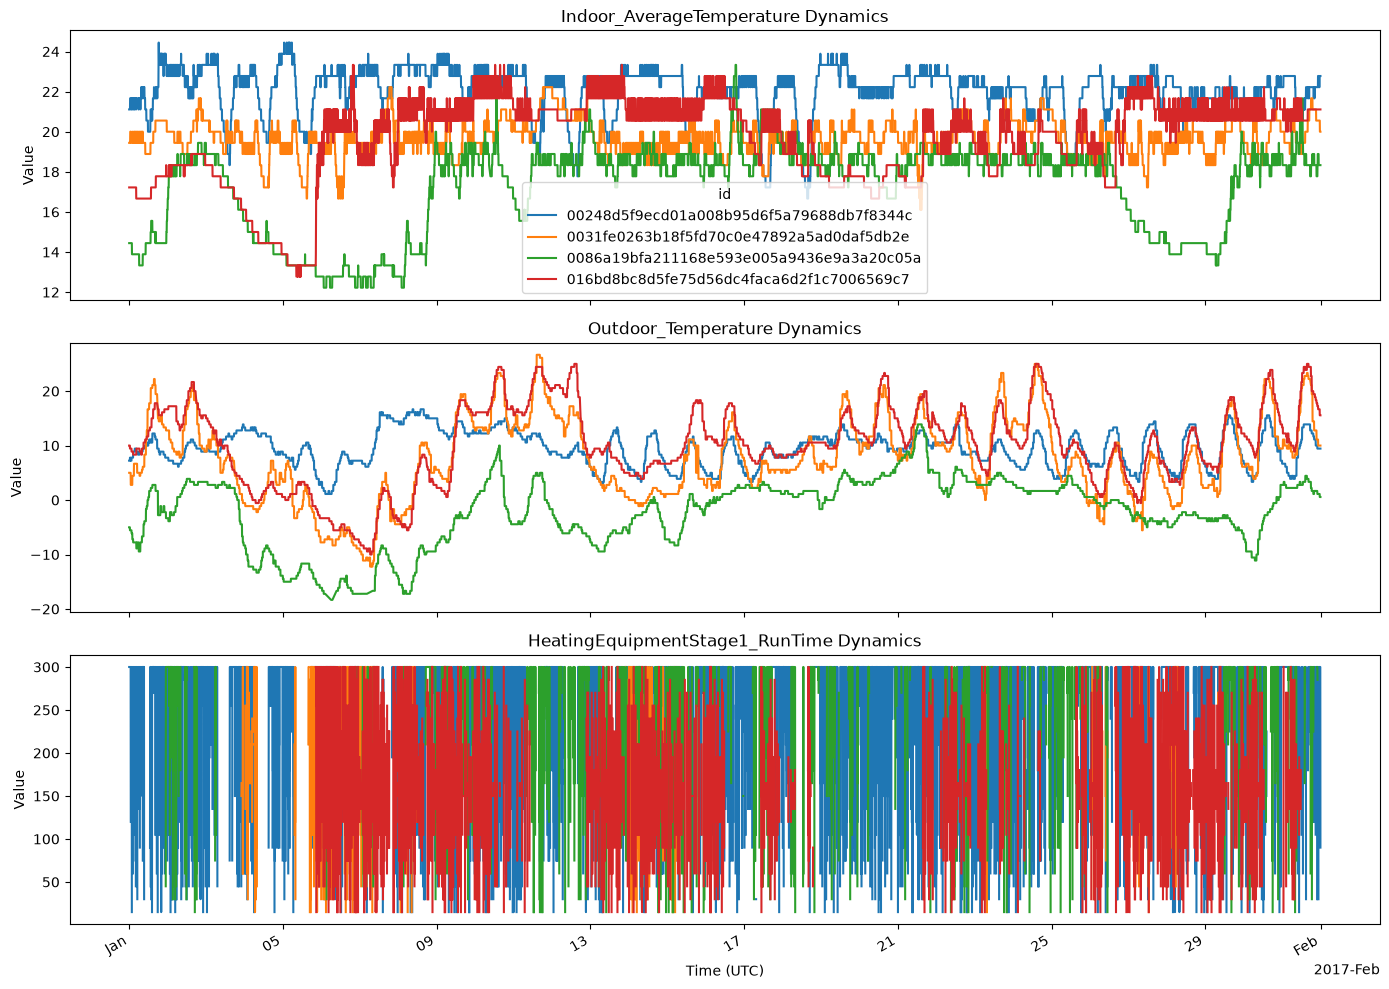

In [2]:
# 1. Select the 3 variables you want to analyze
# I've chosen three related to heating performance, but you can swap these out
variables_to_plot = [
    'Indoor_AverageTemperature', 
    'Outdoor_Temperature', 
    'HeatingEquipmentStage1_RunTime'
]

# 2. Slice the dataset to get exactly 8 IDs
# This takes the first 8 IDs based on their index (0 through 7)
ds_subset = ds.isel(id=slice(0, 4))

# Alternatively, if you want 8 specific string IDs, you would use .sel() instead:
# specific_ids = ['00248d5f...', 'another_id...', ...]
# ds_subset = ds.sel(id=specific_ids)

# 3. Set up the Matplotlib figure with 3 rows, 1 column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# 4. Loop through the chosen variables and plot them on their respective axes
for i, var in enumerate(variables_to_plot):
    ax = axes[i]

    # convert Fahreheint to Celsius if temperature variable
    if 'Temperature' in var:
        ds_subset[var] = (ds_subset[var] - 32) * 5.0/9.0
    
    # By passing hue='id', xarray automatically plots 8 separate lines on this axis
    # We only add the legend to the top plot to keep the layout clean
    ds_subset[var].plot(
        ax=ax, 
        hue='id', 
        add_legend=(i == 0) 
    )
    
    # Formatting
    ax.set_title(f'{var} Dynamics')
    ax.set_ylabel('Value')
    
    # Remove x-axis label for the top two plots to avoid clutter
    if i < 2:
        ax.set_xlabel('')

# Format the datetime strings on the x-axis so they don't overlap
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# convert dataset to CityLearn format

In [3]:
from ecobee_to_citylearn import convert

# ds is your already-open xarray Dataset
schema_path = convert(ds, out_dir="ecobee_dataset", building_ids=ds.id.values[:1])


────────────────────────────────────────────────────────────────────
Ecobee → CityLearn conversion report
────────────────────────────────────────────────────────────────────
Output: C:\Users\carlv\Documents\Projects\LLMSmartHomes\ecobee_dataset
Buildings: 1   Hourly rows/file: 744 (31 days)

UNIT CONVERSIONS APPLIED:
  ✓ Indoor_AverageTemperature (°F→°C)
  ✓ Indoor_CoolSetpoint (°F→°C)
  ✓ Indoor_HeatSetpoint (°F→°C)
  ✓ Outdoor_Temperature (°F→°C)

DERIVED (approximated, check assumptions):
  • cooling_demand/heating_demand (from runtimes × assumed kW)

SYNTHETIC / PLACEHOLDER (no real source in dataset):
  ⚠ carbon_intensity.csv (flat 0.15 placeholder — bring real grid data)
  ⚠ dhw_demand (all zero)
  ⚠ diffuse_solar_irradiance (all zero — bring real weather file)
  ⚠ direct_solar_irradiance (all zero — bring real weather file)
  ⚠ non_shiftable_load (no metered load; flat base + fan only)
  ⚠ pricing.csv (flat $0.22/kWh placeholder — bring a real tariff)
  ⚠ solar_generation (all